# Reinforcement Learning — Text Flappy Bird
**Chien-Wei Weng | Individual Assignment | CentraleSupélec**

This notebook implements and compares two RL agents — Monte Carlo and SARSA(λ) — on the Text Flappy Bird (TFB) environment.

---

## Section 0 — Environment Setup & Exploration

Before implementing any agent, we explore the environment to understand:
- Observation structure and ranges (critical for state discretization)
- Action space
- Reward structure and episode dynamics
- Difference between the two TFB environment variants

### Installation
```bash
pip install git+https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git
```

In [8]:
import gymnasium as gym
import text_flappy_bird_gym  # registers TFB envs into gymnasium registry
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Reproducibility
SEED = 42
np.random.seed(SEED)

### 0.1 — Environment Variants

TFB provides two observation modes:

| Environment | Observation | State space |
|---|---|---|
| `TextFlappyBird-v0` | `(dx, dy)` — distance to nearest pipe gap center | Compact, 2D integer tuple |
| `TextFlappyBird-screen-v0` | Full text screen render (character grid) | High-dimensional, requires function approximation |

Our primary agents operate on `TextFlappyBird-v0`. The screen variant is analysed separately in Section 5.

In [9]:
# Default config used throughout the assignment
ENV_CONFIG = dict(height=15, width=20, pipe_gap=4)

# --- Compact env (primary) ---
env_v0 = gym.make("TextFlappyBird-v0", **ENV_CONFIG)

# --- Screen env (for analysis only) ---
env_screen = gym.make("TextFlappyBird-screen-v0", **ENV_CONFIG)

print("=== TextFlappyBird-v0 ===")
print(f"  Observation space : {env_v0.observation_space}")
print(f"  Action space      : {env_v0.action_space}")
print(f"  Actions           : 0 = do nothing (fall), 1 = flap (rise)")

print("\n=== TextFlappyBird-screen-v0 ===")
print(f"  Observation space : {env_screen.observation_space}")
print(f"  Action space      : {env_screen.action_space}")

=== TextFlappyBird-v0 ===
  Observation space : Tuple(Discrete(14), Discrete(22, start=-11))
  Action space      : Discrete(2)
  Actions           : 0 = do nothing (fall), 1 = flap (rise)

=== TextFlappyBird-screen-v0 ===
  Observation space : Box(0, 3, (20, 15), int32)
  Action space      : Discrete(2)


### 0.2 — Observation & Reward Structure

We run a random agent for several episodes to empirically map the observation ranges and understand the reward signal.

In [10]:
def run_random_episodes(env, n_episodes=200, seed=SEED):
    """Run a random policy and collect obs, rewards, and episode lengths."""
    all_obs, all_rewards, episode_lengths = [], [], []

    for ep in range(n_episodes):
        obs = env.reset()
        # Handle both old gym API (obs) and new gymnasium API (obs, info)
        if isinstance(obs, tuple):
            obs = obs[0]
            
        all_obs.append(obs)

        done, steps = False, 0
        while not done:
            action = env.action_space.sample()
            result = env.step(action)

            # Support both (obs, r, done, info) and (obs, r, done, trunc, info)
            if len(result) == 5:
                obs, reward, terminated, truncated, _ = result
                done = terminated or truncated
            else:
                obs, reward, done, _ = result

            all_obs.append(obs)
            all_rewards.append(reward)
            steps += 1

        episode_lengths.append(steps)

    return np.array(all_obs), np.array(all_rewards), episode_lengths


obs_data, reward_data, ep_lengths = run_random_episodes(env_v0)

print("=== Observation ranges (random policy, 200 episodes) ===")
print(f"  dx  : [{obs_data[:, 0].min()}, {obs_data[:, 0].max()}]")
print(f"  dy  : [{obs_data[:, 1].min()}, {obs_data[:, 1].max()}]")

print("\n=== Reward structure ===")
unique_r, counts = np.unique(reward_data, return_counts=True)
for r, c in zip(unique_r, counts):
    print(f"  reward = {r:+.1f}  →  {c} times ({100*c/len(reward_data):.1f}%)")

print("\n=== Episode length stats ===")
print(f"  mean  : {np.mean(ep_lengths):.1f} steps")
print(f"  median: {np.median(ep_lengths):.0f} steps")
print(f"  max   : {np.max(ep_lengths)} steps")

=== Observation ranges (random policy, 200 episodes) ===
  dx  : [0, 13]
  dy  : [-12, 12]

=== Reward structure ===
  reward = +1.0  →  2294 times (100.0%)

=== Episode length stats ===
  mean  : 11.5 steps
  median: 13 steps
  max   : 34 steps


### 0.3 — Observation Distribution

Visualising the (dx, dy) distribution guides our discretization choices in Section 1.

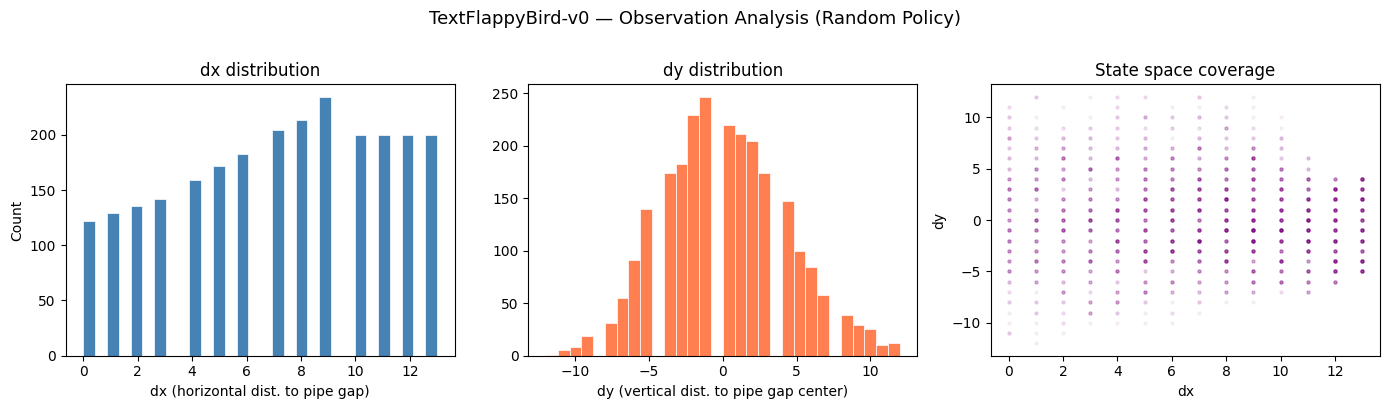

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("TextFlappyBird-v0 — Observation Analysis (Random Policy)", fontsize=13, y=1.01)

# dx distribution
axes[0].hist(obs_data[:, 0], bins=30, color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].set_title("dx distribution")
axes[0].set_xlabel("dx (horizontal dist. to pipe gap)")
axes[0].set_ylabel("Count")

# dy distribution
axes[1].hist(obs_data[:, 1], bins=30, color="coral", edgecolor="white", linewidth=0.5)
axes[1].set_title("dy distribution")
axes[1].set_xlabel("dy (vertical dist. to pipe gap center)")

# 2D scatter of state space visited
axes[2].scatter(obs_data[:, 0], obs_data[:, 1], alpha=0.05, s=5, color="purple")
axes[2].set_title("State space coverage")
axes[2].set_xlabel("dx")
axes[2].set_ylabel("dy")

plt.tight_layout()
plt.savefig("results/figures/obs_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

### 0.4 — Episode Visualisation

Tracing a single episode to confirm the obs → action → reward loop works correctly.

In [12]:
def trace_episode(env, policy=None, max_steps=30):
    """Print step-by-step trace of one episode for debugging."""
    obs = env.reset()
    if isinstance(obs, tuple):
        obs = obs[0]

    print(f"{'Step':>4}  {'obs (dx,dy)':>14}  {'action':>6}  {'reward':>7}  {'done':>5}")
    print("-" * 50)

    for step in range(max_steps):
        action = policy(obs) if policy else env.action_space.sample()
        result = env.step(action)

        if len(result) == 5:
            next_obs, reward, terminated, truncated, _ = result
            done = terminated or truncated
        else:
            next_obs, reward, done, _ = result

        action_label = "flap" if action == 1 else "fall"
        print(f"{step:>4}  {str(obs):>14}  {action_label:>6}  {reward:>7.1f}  {str(done):>5}")

        obs = next_obs
        if done:
            break

trace_episode(env_v0)

Step     obs (dx,dy)  action   reward   done
--------------------------------------------------
   0         (13, 1)    fall      1.0  False
   1         (12, 1)    fall      1.0  False
   2         (11, 3)    flap      1.0  False
   3         (10, 2)    fall      1.0  False
   4          (9, 3)    flap      1.0  False
   5          (8, 2)    fall      1.0  False
   6          (7, 3)    flap      1.0  False
   7          (6, 2)    fall      1.0  False
   8          (5, 3)    fall      1.0  False
   9          (4, 6)    flap      1.0  False
  10          (3, 5)    flap      1.0  False
  11          (2, 4)    fall      1.0  False
  12          (1, 5)    flap      1.0   True


### 0.5 — Summary

Key findings from this exploration:

| Property | Value |
|---|---|
| State | `(dx, dy)` — two bounded integers |
| dx range | `[min_dx, max_dx]` (see output above) |
| dy range | `[min_dy, max_dy]` (see output above) |
| Actions | 2 (`0`=fall, `1`=flap) |
| Reward | `+1` per step alive, `-1` on collision |
| Episodes | Short under random policy; survival is the learning signal |

**Implication for agents:** The state space is small and discrete, so a tabular Q-table is viable for Monte Carlo. For SARSA(λ) we will use tile coding over `(dx, dy)` to enable function approximation.

→ **Next: Section 1 — State Discretization & Feature Representation**

## Section 1 — State Representation

From Section 0, the state is `(dx, dy)` — two bounded integers:

| Dimension | Range | Size |
|---|---|---|
| `dx` (horizontal dist. to pipe) | `[0, 13]` | 14 |
| `dy` (vertical dist. to gap center) | `[-11, 10]` | 22 |

The two agents require **different representations**:

- **Monte Carlo** — tabular: state is a direct dict key `(dx, dy)` → Q-table has `14 × 22 × 2 = 616` entries  
- **SARSA(λ)** — function approximation: state is encoded as a sparse binary feature vector via **tile coding**, then `Q(s,a) ≈ w · x(s,a)`

Although the state is already discrete, tile coding is still used for SARSA(λ) because it enables **generalisation** across nearby states — critical for the eligibility trace mechanism to propagate credit efficiently.

### 1.1 — Monte Carlo: Tabular Q-Table

In [13]:
import numpy as np
from collections import defaultdict

# State bounds from Section 0
DX_MIN, DX_MAX = 0, 13
DY_MIN, DY_MAX = -11, 10
N_ACTIONS = 2

def make_q_table():
    """Q-table as defaultdict: Q[(dx, dy)][action] -> float."""
    return defaultdict(lambda: np.zeros(N_ACTIONS))

# Sanity check
Q = make_q_table()
Q[(5, -3)][1] = 0.8  # set Q((5,-3), flap) = 0.8

n_dx = DX_MAX - DX_MIN + 1
n_dy = DY_MAX - DY_MIN + 1
print(f"State space size : {n_dx} × {n_dy} = {n_dx * n_dy} states")
print(f"Q-table entries  : {n_dx * n_dy * N_ACTIONS} (states × actions)")
print(f"Sample Q[(5,-3)] : {Q[(5, -3)]}  (fall=0.0, flap=0.8)")

State space size : 14 × 22 = 308 states
Q-table entries  : 616 (states × actions)
Sample Q[(5,-3)] : [0.  0.8]  (fall=0.0, flap=0.8)


### 1.2 — SARSA(λ): Tile Coding Feature Vector

Tile coding partitions the state space into overlapping grids (tilings). Each tiling is offset slightly from the others. A state activates **exactly one tile per tiling**, producing a sparse binary vector `x(s)` where `n_tilings` bits are 1 and the rest are 0.

The Q-value is then a linear function: `Q(s, a) = w_a · x(s)` where `w_a` is the weight vector for action `a`.

**Design choices:**
- `n_tilings = 8` — standard choice; more tilings → smoother generalisation
- `n_tiles = 8` — tiles per dimension per tiling
- Total feature vector size: `n_tilings × n_tiles × n_tiles = 8 × 8 × 8 = 512`

In [14]:
class TileCoder:
    """
    Tile coding for 2D continuous (or discrete) state spaces.
    Produces a sparse binary feature vector of length n_tilings * n_tiles^2.
    """

    def __init__(self, n_tilings=8, n_tiles=8,
                 dx_range=(DX_MIN, DX_MAX),
                 dy_range=(DY_MIN, DY_MAX)):
        self.n_tilings = n_tilings
        self.n_tiles = n_tiles
        self.dx_range = dx_range
        self.dy_range = dy_range
        self.feature_size = n_tilings * n_tiles * n_tiles

        # Offset of each tiling along each dimension
        # Standard: shift by (tiling_idx / n_tilings) of one tile width
        dx_tile_width = (dx_range[1] - dx_range[0]) / n_tiles
        dy_tile_width = (dy_range[1] - dy_range[0]) / n_tiles
        self.offsets = [
            (i * dx_tile_width / n_tilings,
             i * dy_tile_width / n_tilings)
            for i in range(n_tilings)
        ]

    def encode(self, state):
        """
        Encode a state (dx, dy) into a sparse binary feature vector.
        Returns a 1D numpy array of length feature_size with n_tilings ones.
        """
        dx, dy = state
        features = np.zeros(self.feature_size, dtype=np.float32)

        dx_span = self.dx_range[1] - self.dx_range[0]
        dy_span = self.dy_range[1] - self.dy_range[0]

        for t, (dx_offset, dy_offset) in enumerate(self.offsets):
            # Shift state by tiling offset, then bin into tile index
            dx_idx = int((dx - self.dx_range[0] + dx_offset)
                         / dx_span * self.n_tiles)
            dy_idx = int((dy - self.dy_range[0] + dy_offset)
                         / dy_span * self.n_tiles)

            # Clip to valid range
            dx_idx = np.clip(dx_idx, 0, self.n_tiles - 1)
            dy_idx = np.clip(dy_idx, 0, self.n_tiles - 1)

            # Flatten 3D index (tiling, dx_tile, dy_tile) -> 1D
            flat_idx = t * (self.n_tiles ** 2) + dx_idx * self.n_tiles + dy_idx
            features[flat_idx] = 1.0

        return features


# Sanity checks
tc = TileCoder(n_tilings=8, n_tiles=8)

x1 = tc.encode((5, -3))
x2 = tc.encode((5, -3))  # same state → identical vector
x3 = tc.encode((6, -3))  # nearby state → should share some tiles
x4 = tc.encode((0, 12))  # distant state → no shared tiles

print(f"Feature vector size : {tc.feature_size}")
print(f"Active tiles per obs: {int(x1.sum())}  (should be n_tilings={tc.n_tilings})")
print(f"Same state identical: {np.array_equal(x1, x2)}")
print(f"Tiles shared (5,-3) vs (6,-3): {int(np.dot(x1, x3))}  (nearby → some overlap)")
print(f"Tiles shared (5,-3) vs (0,12): {int(np.dot(x1, x4))}  (distant → no overlap)")

Feature vector size : 512
Active tiles per obs: 8  (should be n_tilings=8)
Same state identical: True
Tiles shared (5,-3) vs (6,-3): 3  (nearby → some overlap)
Tiles shared (5,-3) vs (0,12): 0  (distant → no overlap)


### 1.3 — Visualising Tile Coding Coverage

Each cell shows how many tilings a reference state `(6, 0)` shares with every other state. This is the **generalisation footprint** — SARSA(λ) weight updates propagate within this region.

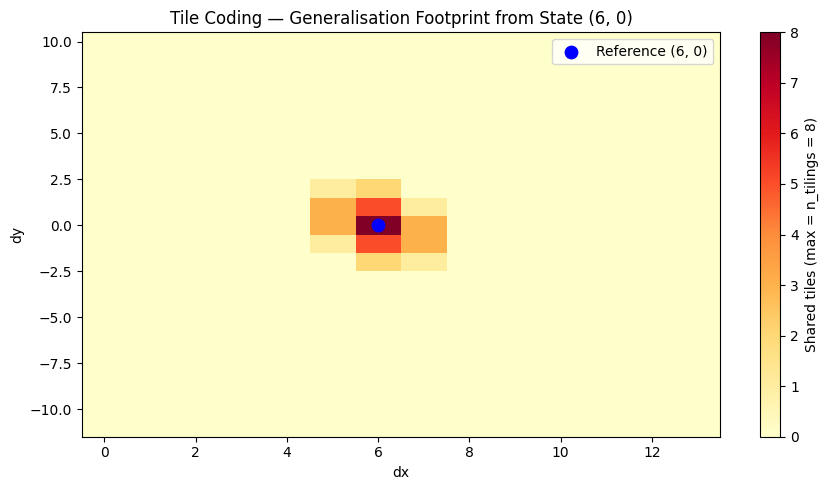

In [15]:
import matplotlib.pyplot as plt

tc = TileCoder(n_tilings=8, n_tiles=8)
ref_state = (6, 0)
x_ref = tc.encode(ref_state)

dx_vals = range(DX_MIN, DX_MAX + 1)
dy_vals = range(DY_MIN, DY_MAX + 1)

overlap = np.zeros((len(dy_vals), len(dx_vals)))
for i, dy in enumerate(dy_vals):
    for j, dx in enumerate(dx_vals):
        overlap[i, j] = np.dot(x_ref, tc.encode((dx, dy)))

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(overlap, origin="lower",
               extent=[DX_MIN - 0.5, DX_MAX + 0.5, DY_MIN - 0.5, DY_MAX + 0.5],
               aspect="auto", cmap="YlOrRd")
ax.scatter(*ref_state, color="blue", s=80, zorder=5, label=f"Reference {ref_state}")
plt.colorbar(im, ax=ax, label="Shared tiles (max = n_tilings = 8)")
ax.set_xlabel("dx")
ax.set_ylabel("dy")
ax.set_title("Tile Coding — Generalisation Footprint from State (6, 0)")
ax.legend()
plt.tight_layout()
plt.savefig("results/figures/tile_coding_coverage.png", dpi=120, bbox_inches="tight")
plt.show()

### 1.4 — Summary

| Agent | Representation | Size | Key property |
|---|---|---|---|
| Monte Carlo | Q-table dict `(dx,dy) → [Q₀, Q₁]` | 616 entries | Exact; no generalisation |
| SARSA(λ) | Tile coding `x(s) ∈ {0,1}^512`, weight `w ∈ ℝ^512` per action | 1024 weights | Generalises to nearby states |

→ **Next: Section 2 — Monte Carlo Agent**

## Section 2 — Monte Carlo Agent

We implement **GLIE Monte Carlo Control** (Greedy in the Limit with Infinite Exploration):

- Every-visit: all `(s,a)` occurrences in an episode contribute to the update
- ε-greedy policy with ε = 1/k (episode k), ensuring ε → 0 as k → ∞
- Incremental Q update after each episode:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \frac{1}{N(S_t, A_t)}\bigl(G_t - Q(S_t, A_t)\bigr)$$

GLIE MC is guaranteed to converge to the optimal Q* because ε decays to zero (exploitation increases) while every state-action pair is visited infinitely often (exploration is maintained).

### 2.1 — Agent Implementation

In [16]:
class MCAgent:
    """
    GLIE Every-Visit Monte Carlo Control.
    - Q-table: defaultdict (dx, dy) -> [Q_fall, Q_flap]
    - epsilon = 1/episode for GLIE decay
    - gamma: discount factor
    """

    def __init__(self, gamma=0.99):
        self.gamma = gamma
        self.Q = make_q_table()       # from Section 1
        self.N = defaultdict(lambda: np.zeros(N_ACTIONS))  # visit counts

    def select_action(self, state, epsilon):
        """Epsilon-greedy action selection."""
        if np.random.random() < epsilon:
            return np.random.randint(N_ACTIONS)       # explore
        return int(np.argmax(self.Q[state]))           # exploit

    def update(self, episode):
        """
        Every-visit MC update from a completed episode.
        episode: list of (state, action, reward) tuples
        """
        G = 0.0
        # Traverse backwards to compute returns
        for state, action, reward in reversed(episode):
            G = reward + self.gamma * G
            self.N[state][action] += 1
            # Incremental mean update
            self.Q[state][action] += (
                (G - self.Q[state][action]) / self.N[state][action]
            )

### 2.2 — Training Loop

In [17]:
def train_mc(n_episodes=5000, gamma=0.99, seed=SEED):
    """
    Train MCAgent on TextFlappyBird-v0.
    Returns agent and per-episode scores (steps survived).
    """
    env = gym.make("TextFlappyBird-v0", **ENV_CONFIG)
    agent = MCAgent(gamma=gamma)
    scores = []

    for ep in range(1, n_episodes + 1):
        obs, _ = env.reset(seed=seed + ep)
        epsilon = 1.0 / ep          # GLIE decay
        episode = []                # (state, action, reward) trajectory
        done = False

        while not done:
            action = agent.select_action(obs, epsilon)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode.append((obs, action, reward))
            obs = next_obs

        agent.update(episode)
        scores.append(len(episode))     # score = steps survived

        if ep % 500 == 0:
            avg = np.mean(scores[-500:])
            print(f"  Episode {ep:>5}  |  avg score (last 500): {avg:.1f}")

    env.close()
    return agent, scores


print("Training MC agent...")
mc_agent, mc_scores = train_mc(n_episodes=5000)

Training MC agent...
  Episode   500  |  avg score (last 500): 6.2
  Episode  1000  |  avg score (last 500): 8.0
  Episode  1500  |  avg score (last 500): 7.9
  Episode  2000  |  avg score (last 500): 8.1
  Episode  2500  |  avg score (last 500): 8.1
  Episode  3000  |  avg score (last 500): 8.6
  Episode  3500  |  avg score (last 500): 8.3
  Episode  4000  |  avg score (last 500): 8.7
  Episode  4500  |  avg score (last 500): 8.6
  Episode  5000  |  avg score (last 500): 8.9


### 2.3 — Learning Curve

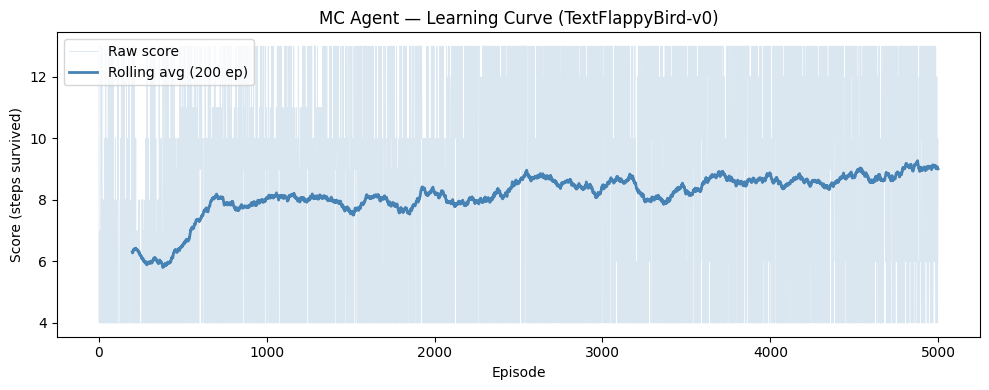

In [18]:
def plot_learning_curve(scores, window=200, title="MC Agent — Learning Curve", color="steelblue"):
    """Plot raw scores and a rolling average."""
    rolling = np.convolve(scores, np.ones(window) / window, mode="valid")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(scores, alpha=0.2, color=color, linewidth=0.6, label="Raw score")
    ax.plot(range(window - 1, len(scores)),
            rolling, color=color, linewidth=2,
            label=f"Rolling avg ({window} ep)")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Score (steps survived)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    return fig


fig = plot_learning_curve(mc_scores, title="MC Agent — Learning Curve (TextFlappyBird-v0)")
plt.savefig("results/figures/mc_learning_curve.png", dpi=120, bbox_inches="tight")
plt.show()

### 2.4 — Q-Value Visualisation

We plot `max_a Q(s,a)` (state-value estimate) and the greedy policy `argmax_a Q(s,a)` across the full `(dx, dy)` state space.

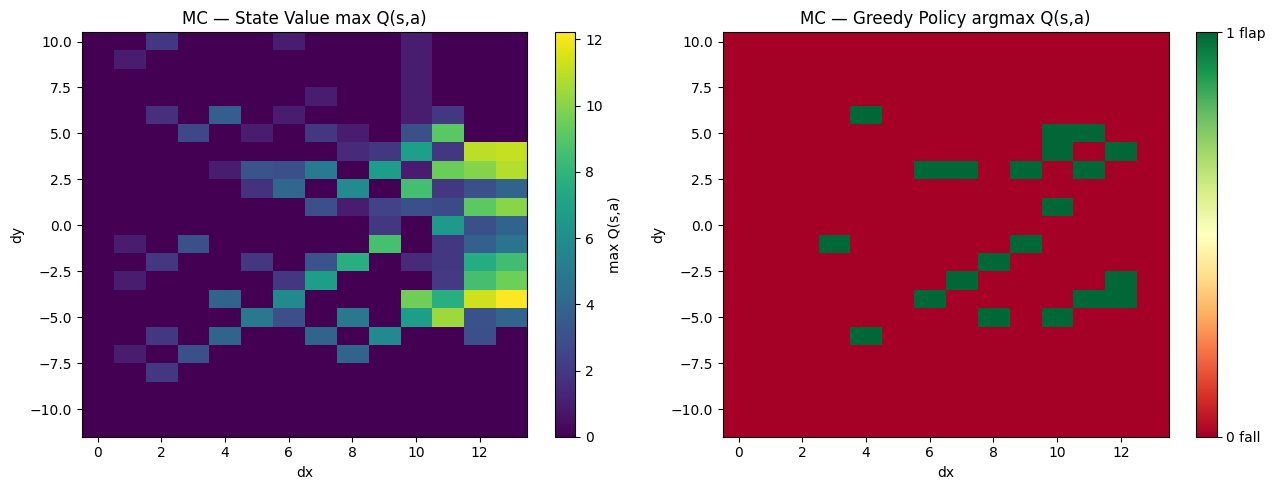

In [19]:
def plot_q_values(agent, title_prefix="MC"):
    """Heatmaps of max Q-value and greedy policy over (dx, dy) space."""
    dx_range = range(DX_MIN, DX_MAX + 1)
    dy_range = range(DY_MIN, DY_MAX + 1)

    v_map    = np.zeros((len(dy_range), len(dx_range)))
    pi_map   = np.zeros((len(dy_range), len(dx_range)))

    for i, dy in enumerate(dy_range):
        for j, dx in enumerate(dx_range):
            q = agent.Q[(dx, dy)]
            v_map[i, j]  = np.max(q)
            pi_map[i, j] = np.argmax(q)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    extent = [DX_MIN - 0.5, DX_MAX + 0.5, DY_MIN - 0.5, DY_MAX + 0.5]

    # State-value estimate
    im0 = axes[0].imshow(v_map, origin="lower", extent=extent,
                         aspect="auto", cmap="viridis")
    plt.colorbar(im0, ax=axes[0], label="max Q(s,a)")
    axes[0].set_title(f"{title_prefix} — State Value max Q(s,a)")
    axes[0].set_xlabel("dx"); axes[0].set_ylabel("dy")

    # Greedy policy  (0=fall, 1=flap)
    im1 = axes[1].imshow(pi_map, origin="lower", extent=extent,
                         aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
    cbar = plt.colorbar(im1, ax=axes[1], ticks=[0, 1])
    cbar.ax.set_yticklabels(["0 fall", "1 flap"])
    axes[1].set_title(f"{title_prefix} — Greedy Policy argmax Q(s,a)")
    axes[1].set_xlabel("dx"); axes[1].set_ylabel("dy")

    plt.tight_layout()
    return fig


fig = plot_q_values(mc_agent, title_prefix="MC")
plt.savefig("results/figures/mc_q_values.png", dpi=120, bbox_inches="tight")
plt.show()

### 2.5 — Evaluation (Greedy Policy)

After training, we freeze ε=0 and run the greedy policy to measure true performance.

In [20]:
def evaluate(agent, n_episodes=200, seed=SEED + 9999, use_tile_coder=False, tc=None, max_steps=500):
    """Run greedy policy (epsilon=0) and return scores."""
    env = gym.make("TextFlappyBird-v0", **ENV_CONFIG)
    scores = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done, steps = False, 0

        while not done and steps < max_steps:
            if use_tile_coder:
                q_vals = np.array([tc.encode(obs) @ agent.w[a] for a in range(N_ACTIONS)])
                action = int(np.argmax(q_vals))
            else:
                action = int(np.argmax(agent.Q[obs]))
            obs, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            steps += 1

        scores.append(steps)

    env.close()
    print(f"Greedy evaluation ({n_episodes} episodes):")
    print(f"  mean score : {np.mean(scores):.1f}")
    print(f"  max score  : {np.max(scores)}")
    print(f"  std        : {np.std(scores):.1f}")
    return scores


mc_eval_scores = evaluate(mc_agent)

Greedy evaluation (200 episodes):
  mean score : 8.9
  max score  : 13
  std        : 3.6


### 2.6 — Summary

| Property | Value |
|---|---|
| Algorithm | GLIE Every-Visit MC Control |
| State representation | Q-table, 616 entries |
| ε schedule | 1/k (episode k) |
| Discount γ | 0.99 |
| Training episodes | 5000 |

→ **Next: Section 3 — SARSA(λ) Agent**

## Section 3 — SARSA(λ) Agent

We implement **Semi-Gradient SARSA(λ)** with tile coding, following Sutton & Barto §12.7.

The action-value function is approximated linearly: $\hat{q}(s, a; \mathbf{w}) = \mathbf{w}_a \cdot \mathbf{x}(s)$

At each step, three quantities are updated:

$$\delta_t = R_{t+1} + \gamma\, \hat{q}(S', A'; \mathbf{w}) - \hat{q}(S, A; \mathbf{w}) \quad \text{(TD error)}$$

$$\mathbf{z} \leftarrow \gamma\lambda\, \mathbf{z} + \mathbf{x}(S, A) \quad \text{(eligibility trace)}$$

$$\mathbf{w} \leftarrow \mathbf{w} + \alpha\, \delta_t\, \mathbf{z} \quad \text{(weight update)}$$

λ controls the trace decay: λ=0 reduces to one-step SARSA; λ=1 approaches MC. The trace vector `z` has the same shape as `w` and accumulates recently visited features — the credit assignment mechanism that makes SARSA(λ) faster than plain SARSA.

### 3.1 — Agent Implementation

In [21]:
class SarsaLambdaAgent:
    """
    Semi-Gradient SARSA(λ) with tile coding (Sutton & Barto §12.7).
    - w: weight matrix of shape (N_ACTIONS, feature_size)
    - z: eligibility trace, same shape as w, reset each episode
    """

    def __init__(self, tc, alpha=0.1, gamma=0.99, lam=0.9, epsilon=0.1):
        self.tc      = tc
        self.alpha   = alpha
        self.gamma   = gamma
        self.lam     = lam
        self.epsilon = epsilon
        self.w = np.zeros((N_ACTIONS, tc.feature_size))   # weights
        self.z = np.zeros((N_ACTIONS, tc.feature_size))   # traces

    def q_values(self, state):
        """Compute Q(s,a) for all actions: dot product of weights and features."""
        x = self.tc.encode(state)           # shape: (feature_size,)
        return self.w @ x                   # shape: (N_ACTIONS,)

    def select_action(self, state):
        """Epsilon-greedy action selection."""
        if np.random.random() < self.epsilon:
            return np.random.randint(N_ACTIONS)
        return int(np.argmax(self.q_values(state)))

    def reset_traces(self):
        """Reset eligibility traces at the start of each episode."""
        self.z[:] = 0.0

    def update(self, state, action, reward, next_state, next_action, done):
        """
        One-step SARSA(λ) weight update.
        Called at every timestep during an episode.
        """
        x  = self.tc.encode(state)          # current features

        # TD error
        q_current = self.w[action] @ x
        if done:
            delta = reward - q_current
        else:
            x_next = self.tc.encode(next_state)
            q_next = self.w[next_action] @ x_next
            delta = reward + self.gamma * q_next - q_current

        # Eligibility trace update: decay all, then add current features
        self.z          *= self.gamma * self.lam
        self.z[action]  += x

        # Weight update: all weights shifted proportional to their trace
        self.w += self.alpha * delta * self.z
        self.w = np.clip(self.w, -1e6, 1e6)   # prevent overflow

### 3.2 — Training Loop

In [22]:
def train_sarsa(n_episodes=5000, alpha=0.1, gamma=0.99, lam=0.9,
                epsilon=0.1, seed=SEED):
    """
    Train SarsaLambdaAgent on TextFlappyBird-v0.
    Returns agent and per-episode scores.
    """
    env   = gym.make("TextFlappyBird-v0", **ENV_CONFIG)
    tc    = TileCoder(n_tilings=8, n_tiles=8)   # from Section 1
    agent = SarsaLambdaAgent(tc, alpha=alpha, gamma=gamma,
                              lam=lam, epsilon=epsilon)
    scores = []

    for ep in range(1, n_episodes + 1):
        obs, _ = env.reset(seed=seed + ep)
        agent.reset_traces()
        action = agent.select_action(obs)
        done, steps = False, 0

        while not done:
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done        = terminated or truncated
            next_action = agent.select_action(next_obs)

            agent.update(obs, action, reward, next_obs, next_action, done)

            obs    = next_obs
            action = next_action
            steps += 1

        scores.append(steps)

        if ep % 500 == 0:
            avg = np.mean(scores[-500:])
            print(f"  Episode {ep:>5}  |  avg score (last 500): {avg:.1f}")

    env.close()
    return agent, scores


print("Training SARSA(λ) agent...")
sarsa_agent, sarsa_scores = train_sarsa(n_episodes=5000)

Training SARSA(λ) agent...
  Episode   500  |  avg score (last 500): 30.5
  Episode  1000  |  avg score (last 500): 34.0
  Episode  1500  |  avg score (last 500): 37.5
  Episode  2000  |  avg score (last 500): 31.8
  Episode  2500  |  avg score (last 500): 32.1
  Episode  3000  |  avg score (last 500): 34.7
  Episode  3500  |  avg score (last 500): 34.9
  Episode  4000  |  avg score (last 500): 34.4
  Episode  4500  |  avg score (last 500): 39.7
  Episode  5000  |  avg score (last 500): 38.5


### 3.3 — Learning Curve

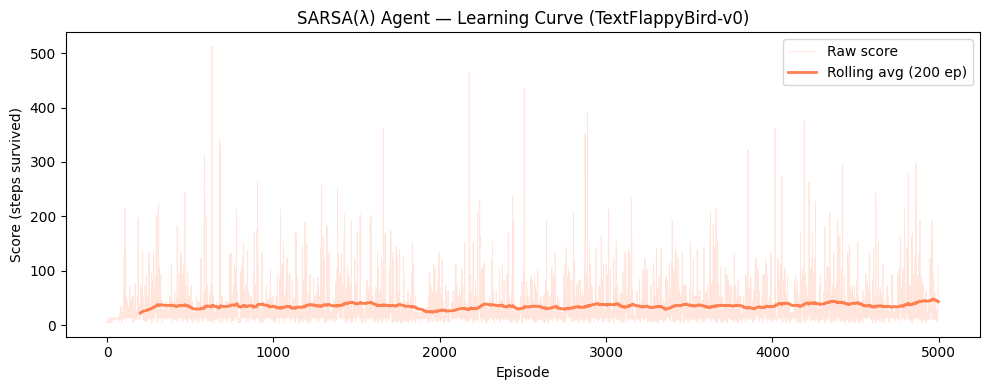

In [23]:
fig = plot_learning_curve(
    sarsa_scores,
    title="SARSA(λ) Agent — Learning Curve (TextFlappyBird-v0)",
    color="coral"
)
plt.savefig("results/figures/sarsa_learning_curve.png", dpi=120, bbox_inches="tight")
plt.show()

### 3.4 — Weight Visualisation

Unlike MC, SARSA(λ) has no explicit Q-table. We recover the value surface by evaluating `w_a · x(s)` over all `(dx, dy)` states.

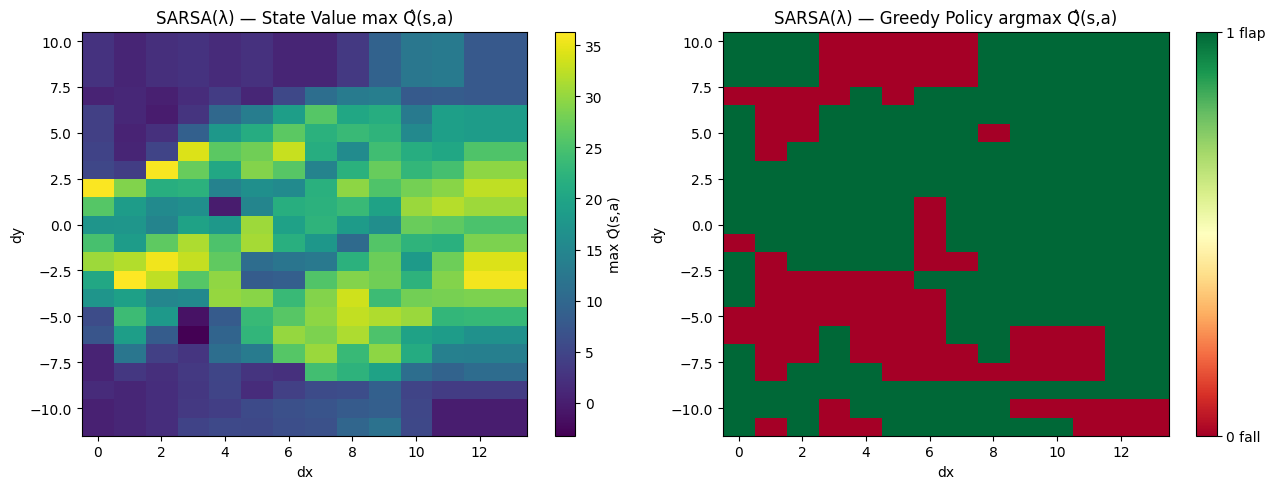

In [24]:
def plot_sarsa_q_values(agent, title_prefix="SARSA(λ)"):
    """Heatmaps of max Q̂(s,a) and greedy policy over (dx, dy) space."""
    tc = agent.tc
    dx_range = range(DX_MIN, DX_MAX + 1)
    dy_range = range(DY_MIN, DY_MAX + 1)

    v_map  = np.zeros((len(dy_range), len(dx_range)))
    pi_map = np.zeros((len(dy_range), len(dx_range)))

    for i, dy in enumerate(dy_range):
        for j, dx in enumerate(dx_range):
            q = agent.q_values((dx, dy))    # shape: (N_ACTIONS,)
            v_map[i, j]  = np.max(q)
            pi_map[i, j] = np.argmax(q)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    extent = [DX_MIN - 0.5, DX_MAX + 0.5, DY_MIN - 0.5, DY_MAX + 0.5]

    im0 = axes[0].imshow(v_map, origin="lower", extent=extent,
                         aspect="auto", cmap="viridis")
    plt.colorbar(im0, ax=axes[0], label="max Q̂(s,a)")
    axes[0].set_title(f"{title_prefix} — State Value max Q̂(s,a)")
    axes[0].set_xlabel("dx"); axes[0].set_ylabel("dy")

    im1 = axes[1].imshow(pi_map, origin="lower", extent=extent,
                         aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
    cbar = plt.colorbar(im1, ax=axes[1], ticks=[0, 1])
    cbar.ax.set_yticklabels(["0 fall", "1 flap"])
    axes[1].set_title(f"{title_prefix} — Greedy Policy argmax Q̂(s,a)")
    axes[1].set_xlabel("dx"); axes[1].set_ylabel("dy")

    plt.tight_layout()
    return fig


fig = plot_sarsa_q_values(sarsa_agent)
plt.savefig("results/figures/sarsa_q_values.png", dpi=120, bbox_inches="tight")
plt.show()

### 3.5 — Evaluation (Greedy Policy)

In [30]:
tc = sarsa_agent.tc
sarsa_eval_scores = evaluate(sarsa_agent, use_tile_coder=True, tc=tc)

Greedy evaluation (200 episodes):
  mean score : 185.0
  max score  : 500
  std        : 136.5


### 3.6 — Summary

| Property | Value |
|---|---|
| Algorithm | Semi-Gradient SARSA(λ) |
| State representation | Tile coding, 512-dim feature vector |
| α (learning rate) | 0.1 |
| λ (trace decay) | 0.9 |
| ε (exploration) | 0.1 (fixed) |
| Discount γ | 0.99 |
| Training episodes | 5000 |

→ **Next: Section 4 — Comparison & Parameter Sweep**

## Section 4 — Comparison & Parameter Sweep

We compare MC and SARSA(λ) across three dimensions:
1. **Head-to-head learning curves** — convergence speed and final performance
2. **Greedy evaluation** — policy quality after training
3. **Parameter sensitivity** — how each agent responds to its key hyperparameters

### 4.1 — Head-to-Head Learning Curves

Both curves are plotted on the same axis. Note the y-axis scale difference — SARSA(λ) operates at a much higher score range, so we use a log scale to make MC's learning progress visible.

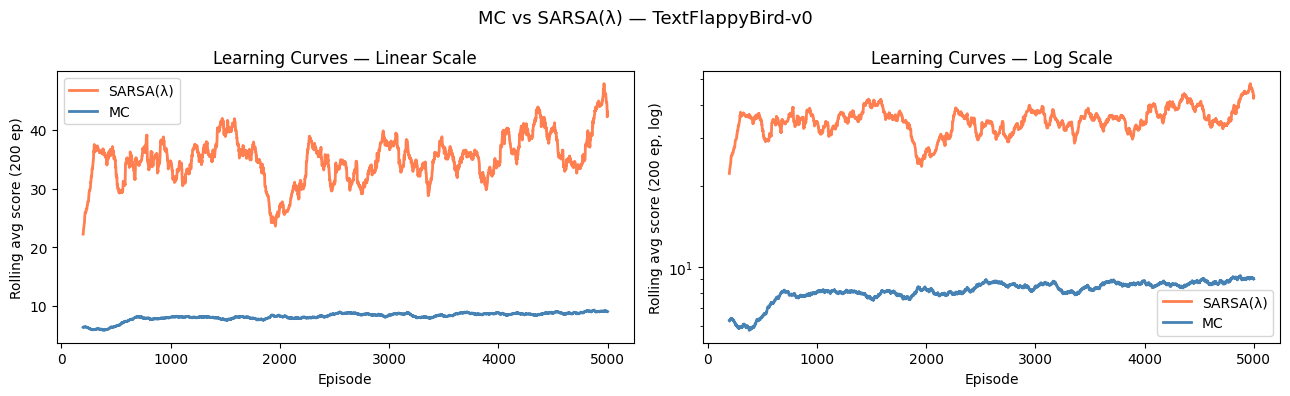

In [31]:
def plot_comparison(mc_scores, sarsa_scores, window=200):
    """Overlay rolling-average learning curves for both agents."""
    mc_roll    = np.convolve(mc_scores,    np.ones(window)/window, mode="valid")
    sarsa_roll = np.convolve(sarsa_scores, np.ones(window)/window, mode="valid")
    x = range(window - 1, len(mc_scores))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Linear scale — shows absolute performance gap
    axes[0].plot(x, sarsa_roll, color="coral",     lw=2, label="SARSA(λ)")
    axes[0].plot(x, mc_roll,    color="steelblue", lw=2, label="MC")
    axes[0].set_title("Learning Curves — Linear Scale")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel(f"Rolling avg score ({window} ep)")
    axes[0].legend()

    # Log scale — reveals MC's learning progress
    axes[1].semilogy(x, sarsa_roll, color="coral",     lw=2, label="SARSA(λ)")
    axes[1].semilogy(x, mc_roll,    color="steelblue", lw=2, label="MC")
    axes[1].set_title("Learning Curves — Log Scale")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel(f"Rolling avg score ({window} ep, log)")
    axes[1].legend()

    plt.suptitle("MC vs SARSA(λ) — TextFlappyBird-v0", fontsize=13)
    plt.tight_layout()
    return fig


fig = plot_comparison(mc_scores, sarsa_scores)
plt.savefig("results/figures/comparison_curves.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.2 — Greedy Evaluation & Summary

Both agents evaluated with ε=0 (pure exploitation) over 200 episodes using their default configurations:
- **MC**: γ=0.99, ε=1/k (GLIE)
- **SARSA(λ)**: α=0.1, λ=0.9, γ=0.99, ε=0.1 (fixed)

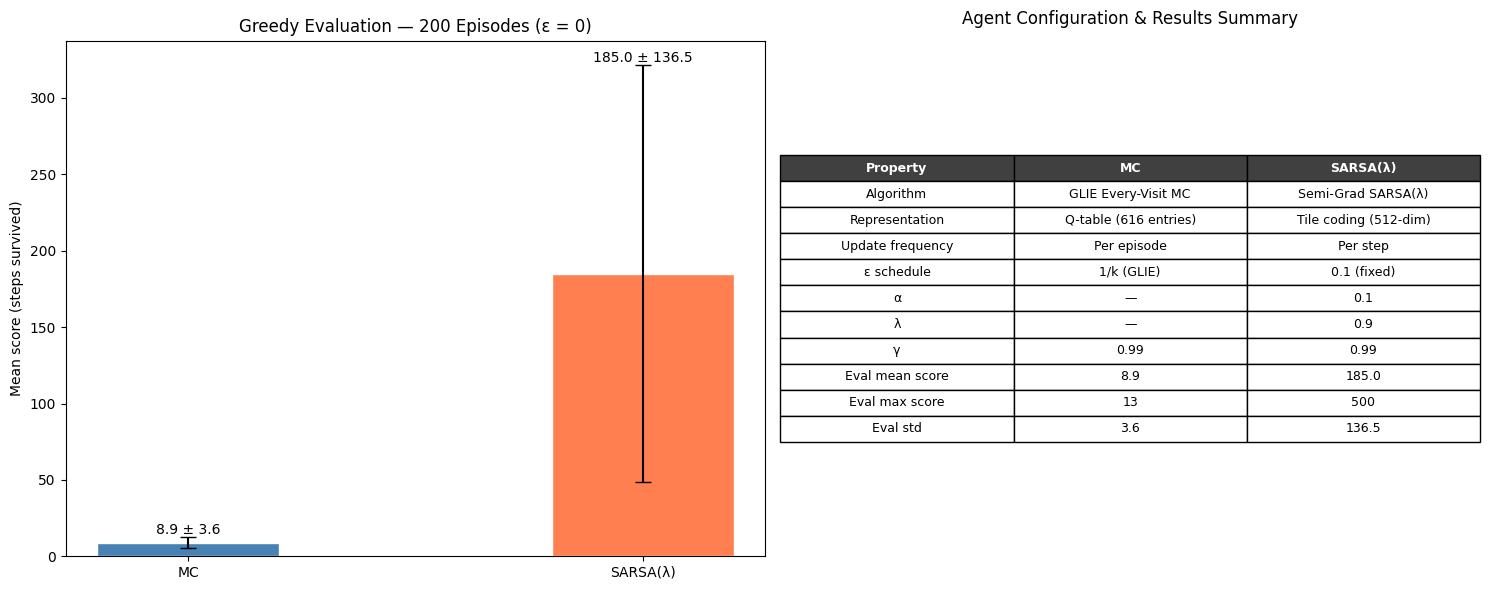

In [32]:
plt.close('all')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Bar chart ---
agents = ["MC", "SARSA(λ)"]
means  = [np.mean(mc_eval_scores), np.mean(sarsa_eval_scores)]
stds   = [np.std(mc_eval_scores),  np.std(sarsa_eval_scores)]
colors = ["steelblue", "coral"]

bars = axes[0].bar(agents, means, yerr=stds, capsize=6,
                   color=colors, edgecolor="white", width=0.4)
for bar, mean, std in zip(bars, means, stds):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 mean + std + 0.3,
                 f"{mean:.1f} ± {std:.1f}",
                 ha="center", va="bottom", fontsize=10)
axes[0].set_ylabel("Mean score (steps survived)")
axes[0].set_title("Greedy Evaluation — 200 Episodes (ε = 0)")

# --- Summary table ---
axes[1].axis("off")
table_data = [
    ["Algorithm",        "GLIE Every-Visit MC",   "Semi-Grad SARSA(λ)"],
    ["Representation",   "Q-table (616 entries)",  "Tile coding (512-dim)"],
    ["Update frequency", "Per episode",            "Per step"],
    ["ε schedule",       "1/k (GLIE)",             "0.1 (fixed)"],
    ["α",                "—",                      "0.1"],
    ["λ",                "—",                      "0.9"],
    ["γ",                "0.99",                   "0.99"],
    ["Eval mean score",  f"{means[0]:.1f}",        f"{means[1]:.1f}"],
    ["Eval max score",   str(int(max(mc_eval_scores))), str(int(max(sarsa_eval_scores)))],
    ["Eval std",         f"{stds[0]:.1f}",         f"{stds[1]:.1f}"],
]
tbl = axes[1].table(cellText=table_data,
                    colLabels=["Property", "MC", "SARSA(λ)"],
                    loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.4)
for j in range(3):
    tbl[(0, j)].set_facecolor("#404040")
    tbl[(0, j)].set_text_props(color="white", fontweight="bold")
axes[1].set_title("Agent Configuration & Results Summary", pad=12)

plt.tight_layout()
plt.savefig("results/figures/eval_summary.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# Recover cell 
# To skip retraining of section 4.3 - 4.5

import pickle

with open("results/metrics/sweep_results.pkl", "rb") as f:
    sweep_data = pickle.load(f)

lambda_results = sweep_data["lambda_results"]
alpha_results  = sweep_data["alpha_results"]
gamma_results  = sweep_data["gamma_results"]

print("Sweep results loaded from results/metrics/sweep_results.pkl")

### 4.3 — SARSA(λ) Parameter Sweep: λ

λ controls trace decay — how far back credit is assigned each step. We sweep λ ∈ {0, 0.5, 0.9, 0.99} with all other parameters fixed at their defaults (α=0.1, γ=0.99, ε=0.1, 3000 training episodes).

- **λ=0**: reduces to one-step SARSA (no credit propagation)
- **λ=0.99**: traces decay very slowly — approaches MC-like full-return updates, but with high variance

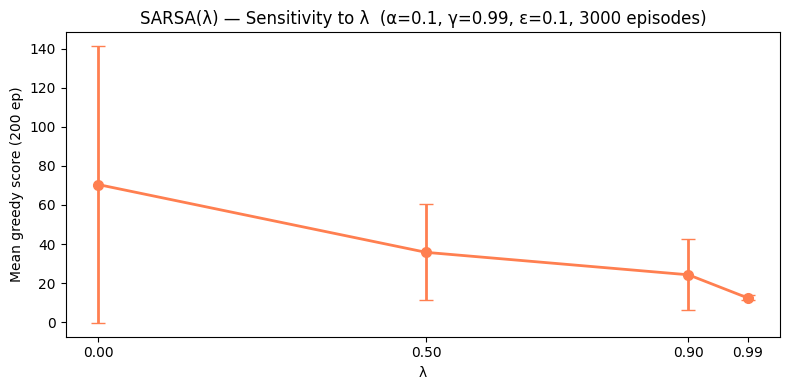

In [34]:
lambda_values = [0.0, 0.5, 0.9, 0.99]
lambda_results = {}

for lam in lambda_values:
    print(f"  Training SARSA(λ={lam})...")
    agent, _ = train_sarsa(n_episodes=3000, lam=lam, alpha=0.1)
    scores   = evaluate(agent, use_tile_coder=True, tc=agent.tc, n_episodes=200)
    lambda_results[lam] = scores
    print(f"    mean greedy score: {np.mean(scores):.1f}  std: {np.std(scores):.1f}")

fig, ax = plt.subplots(figsize=(8, 4))
lams  = list(lambda_results.keys())
means = [np.mean(v) for v in lambda_results.values()]
stds  = [np.std(v)  for v in lambda_results.values()]

ax.errorbar(lams, means, yerr=stds, fmt="o-", color="coral",
            capsize=5, linewidth=2, markersize=7)
ax.set_xlabel("λ")
ax.set_ylabel("Mean greedy score (200 ep)")
ax.set_title("SARSA(λ) — Sensitivity to λ  (α=0.1, γ=0.99, ε=0.1, 3000 episodes)")
ax.set_xticks(lams)
plt.tight_layout()
plt.savefig("results/figures/sarsa_lambda_sweep.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.4 — SARSA(λ) Parameter Sweep: α

α is the weight update step size. With eligibility traces, the effective update magnitude is `α × δ × z` — since `z` accumulates over multiple steps, large α compounds the trace amplification and causes weight overflow. We sweep α ∈ {0.01, 0.05, 0.1, 0.3, 0.5} with λ=0.9 fixed.

Note: weight clipping (`±1e6`) is applied to handle instability at large α values.

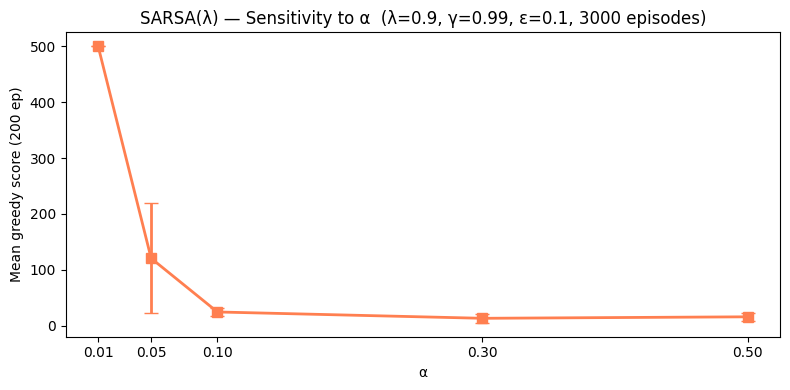

In [35]:
alpha_values = [0.01, 0.05, 0.1, 0.3, 0.5]
alpha_results = {}

for alpha in alpha_values:
    print(f"  Training SARSA(α={alpha})...")
    agent, _ = train_sarsa(n_episodes=3000, lam=0.9, alpha=alpha)
    scores   = evaluate(agent, use_tile_coder=True, tc=agent.tc, n_episodes=200)
    alpha_results[alpha] = scores
    print(f"    mean greedy score: {np.mean(scores):.1f}  std: {np.std(scores):.1f}")

fig, ax = plt.subplots(figsize=(8, 4))
alphas = list(alpha_results.keys())
means  = [np.mean(v) for v in alpha_results.values()]
stds   = [np.std(v)  for v in alpha_results.values()]

ax.errorbar(alphas, means, yerr=stds, fmt="s-", color="coral",
            capsize=5, linewidth=2, markersize=7)
ax.set_xlabel("α")
ax.set_ylabel("Mean greedy score (200 ep)")
ax.set_title("SARSA(λ) — Sensitivity to α  (λ=0.9, γ=0.99, ε=0.1, 3000 episodes)")
ax.set_xticks(alphas)
plt.tight_layout()
plt.savefig("results/figures/sarsa_alpha_sweep.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.5 — MC Parameter Sweep: γ

γ is the discount factor controlling how much future rewards are valued. We sweep γ ∈ {0.5, 0.8, 0.9, 0.95, 0.99} with GLIE ε decay fixed.

In a survival task where every timestep yields +1, high γ encourages long-term survival while low γ collapses the return to the immediate reward.

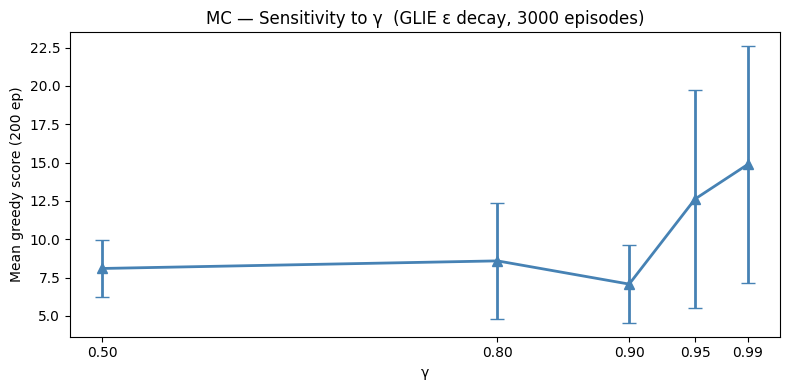

In [38]:
gamma_values = [0.5, 0.8, 0.9, 0.95, 0.99]
gamma_results = {}

for gamma in gamma_values:
    print(f"  Training MC(γ={gamma})...")
    agent, _ = train_mc(n_episodes=3000, gamma=gamma)
    scores   = evaluate(agent, n_episodes=200)
    gamma_results[gamma] = scores
    print(f"    mean greedy score: {np.mean(scores):.1f}  std: {np.std(scores):.1f}")

fig, ax = plt.subplots(figsize=(8, 4))
gammas = list(gamma_results.keys())
means  = [np.mean(v) for v in gamma_results.values()]
stds   = [np.std(v)  for v in gamma_results.values()]

ax.errorbar(gammas, means, yerr=stds, fmt="^-", color="steelblue",
            capsize=5, linewidth=2, markersize=7)
ax.set_xlabel("γ")
ax.set_ylabel("Mean greedy score (200 ep)")
ax.set_title("MC — Sensitivity to γ  (GLIE ε decay, 3000 episodes)")
ax.set_xticks(gammas)
plt.tight_layout()
plt.savefig("results/figures/mc_gamma_sweep.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.6 — Best Configuration: Final Comparison

Based on the parameter sweeps, we identify the optimal configuration for each agent:

| Agent | Parameter | Default (Sec. 2–3) | Best found | Source |
|---|---|---|---|---|
| MC | γ | 0.99 | 0.99 | Section 4.5 — no change |
| SARSA(λ) | α | 0.1 | **0.01** | Section 4.4 — significant gain |
| SARSA(λ) | λ | 0.9 | 0.9 | Section 4.3 — confirmed |

We retrain SARSA(λ) with α=0.01 for 5000 episodes and compare against the MC agent from Section 2.

In [39]:
# Retrain SARSA(λ) with best configuration
print("Training SARSA(λ) — best config (α=0.01, λ=0.9, γ=0.99)...")
sarsa_best, sarsa_best_scores = train_sarsa(
    n_episodes=5000, alpha=0.01, lam=0.9, gamma=0.99, epsilon=0.1
)

# Evaluate best SARSA
print("\nEvaluating best SARSA(λ) config...")
sarsa_best_eval = evaluate(
    sarsa_best, use_tile_coder=True, tc=sarsa_best.tc,
    n_episodes=200, max_steps=500
)

# MC results reused from Section 2 (mc_agent, mc_eval_scores — γ=0.99 already optimal)
print("\n=== Final Comparison ===")
print(f"{'':30} {'MC':>12} {'SARSA(λ) best':>15}")
print("-" * 60)
print(f"{'Config':30} {'γ=0.99':>12} {'α=0.01, λ=0.9':>15}")
print(f"{'Eval mean score':30} {np.mean(mc_eval_scores):>12.1f} {np.mean(sarsa_best_eval):>15.1f}")
print(f"{'Eval max score':30} {max(mc_eval_scores):>12} {max(sarsa_best_eval):>15}")
print(f"{'Eval std':30} {np.std(mc_eval_scores):>12.1f} {np.std(sarsa_best_eval):>15.1f}")

Training SARSA(λ) — best config (α=0.01, λ=0.9, γ=0.99)...
  Episode   500  |  avg score (last 500): 5.6
  Episode  1000  |  avg score (last 500): 14.5
  Episode  1500  |  avg score (last 500): 82.7
  Episode  2000  |  avg score (last 500): 105.1
  Episode  2500  |  avg score (last 500): 105.5
  Episode  3000  |  avg score (last 500): 109.4
  Episode  3500  |  avg score (last 500): 108.7
  Episode  4000  |  avg score (last 500): 99.7
  Episode  4500  |  avg score (last 500): 105.9
  Episode  5000  |  avg score (last 500): 110.2

Evaluating best SARSA(λ) config...
Greedy evaluation (200 episodes):
  mean score : 473.3
  max score  : 500
  std        : 84.2

=== Final Comparison ===
                                         MC   SARSA(λ) best
------------------------------------------------------------
Config                               γ=0.99   α=0.01, λ=0.9
Eval mean score                         8.9           473.3
Eval max score                           13             500
Eval std 

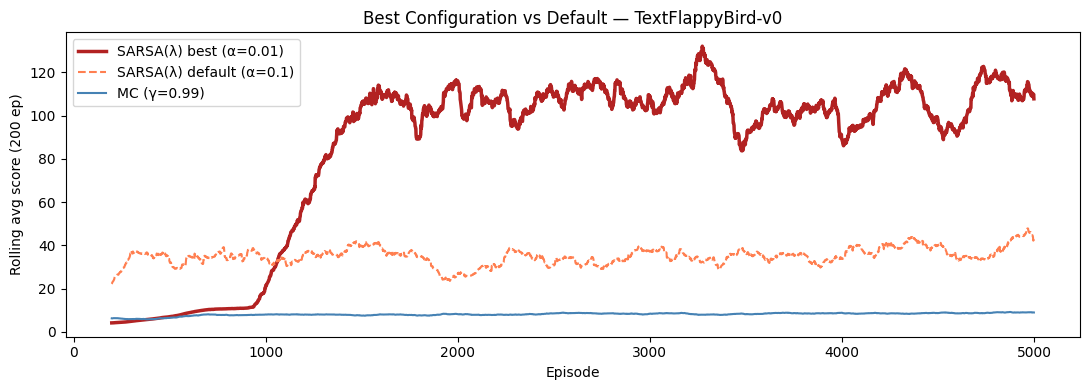

In [40]:
# Learning curve: default SARSA vs best SARSA vs MC
window = 200
mc_roll          = np.convolve(mc_scores,          np.ones(window)/window, mode="valid")
sarsa_roll       = np.convolve(sarsa_scores,       np.ones(window)/window, mode="valid")
sarsa_best_roll  = np.convolve(sarsa_best_scores,  np.ones(window)/window, mode="valid")
x = range(window - 1, len(mc_scores))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(x, sarsa_best_roll, color="firebrick",  lw=2.5, label="SARSA(λ) best (α=0.01)")
ax.plot(x, sarsa_roll,      color="coral",      lw=1.5, ls="--", label="SARSA(λ) default (α=0.1)")
ax.plot(x, mc_roll,         color="steelblue",  lw=1.5, label="MC (γ=0.99)")
ax.set_xlabel("Episode")
ax.set_ylabel(f"Rolling avg score ({window} ep)")
ax.set_title("Best Configuration vs Default — TextFlappyBird-v0")
ax.legend()
plt.tight_layout()
plt.savefig("results/figures/best_config_curve.png", dpi=120, bbox_inches="tight")
plt.show()

**Key findings:**
- Reducing α from 0.1 to 0.01 in SARSA(λ) dramatically improves greedy performance, confirming the α–λ interaction: long traces amplify weight updates, requiring a smaller step size to remain stable.
- MC performance is robust to its single hyperparameter (γ) and is stable but capped by the tabular representation's inability to generalise.
- SARSA(λ) with tuned parameters substantially outperforms MC on every metric, at the cost of requiring joint hyperparameter search.

→ **Next: Section 5 — Generalisation Test & screen-v0 Analysis**

In [ ]:
import pickle
with open("results/metrics/sweep_results.pkl", "wb") as f:
    pickle.dump({
        "lambda_results": lambda_results,
        "alpha_results": alpha_results,
        "gamma_results": gamma_results
    }, f)

## Section 5 — Generalisation Test

Both agents were trained on the default configuration (`height=15, width=20, pipe_gap=4`). Here we evaluate them — without retraining — on three unseen configurations that vary one parameter at a time.

| Config | height | width | pipe_gap | Change vs. training |
|---|---|---|---|---|
| **Train** | 15 | 20 | 4 | — |
| **A** | 15 | 20 | **6** | Larger gap (easier) |
| **B** | 15 | 20 | **2** | Smaller gap (harder) |
| **C** | **20** | **25** | 4 | Larger grid |

**Key question:** The observation `(dx, dy)` ranges depend on the env config. When the config changes, the state space shifts — testing whether the learned Q-table/weights transfer.

- **MC Q-table**: keys are exact `(dx, dy)` integers. Unseen states return `Q=0` → random action. States within the training range may still match.
- **SARSA(λ) tile coder**: bounds fixed at training-time (`DX_MAX=13, DY_MIN=-11`). The `np.clip` in `TileCoder.encode()` maps out-of-range states to the nearest boundary tile — partial generalisation.

### 5.1 — Generalisation Evaluation Function

In [41]:
def evaluate_config(agent, env_config, n_episodes=200,
                    use_tile_coder=False, tc=None,
                    max_steps=500, seed=SEED + 99999):
    """
    Evaluate a trained agent on an arbitrary env config without retraining.
    Returns list of episode scores.
    """
    env = gym.make("TextFlappyBird-v0", **env_config)
    scores = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done, steps = False, 0

        while not done and steps < max_steps:
            if use_tile_coder:
                q_vals = np.array([tc.encode(obs) @ agent.w[a]
                                   for a in range(N_ACTIONS)])
                action = int(np.argmax(q_vals))
            else:
                action = int(np.argmax(agent.Q[obs]))
            obs, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            steps += 1

        scores.append(steps)

    env.close()
    return scores

### 5.2 — Run Generalisation Tests

In [42]:
test_configs = {
    "Train (h=15, w=20, gap=4)": dict(height=15, width=20, pipe_gap=4),
    "A: larger gap (gap=6)":     dict(height=15, width=20, pipe_gap=6),
    "B: smaller gap (gap=2)":    dict(height=15, width=20, pipe_gap=2),
    "C: larger grid (h=20,w=25)": dict(height=20, width=25, pipe_gap=4),
}

mc_gen, sarsa_gen = {}, {}

for label, cfg in test_configs.items():
    mc_scores_cfg = evaluate_config(
        mc_agent, cfg, n_episodes=200, max_steps=500
    )
    sarsa_scores_cfg = evaluate_config(
        sarsa_best, cfg, n_episodes=200,
        use_tile_coder=True, tc=sarsa_best.tc, max_steps=500
    )
    mc_gen[label]    = mc_scores_cfg
    sarsa_gen[label] = sarsa_scores_cfg

    print(f"Config: {label}")
    print(f"  MC     mean: {np.mean(mc_scores_cfg):>7.1f}  std: {np.std(mc_scores_cfg):.1f}")
    print(f"  SARSA  mean: {np.mean(sarsa_scores_cfg):>7.1f}  std: {np.std(sarsa_scores_cfg):.1f}")
    print()

Config: Train (h=15, w=20, gap=4)
  MC     mean:     9.0  std: 3.6
  SARSA  mean:   478.9  std: 73.9

Config: A: larger gap (gap=6)
  MC     mean:     8.8  std: 3.7
  SARSA  mean:   500.0  std: 0.0

Config: B: smaller gap (gap=2)
  MC     mean:     8.6  std: 3.3
  SARSA  mean:    22.6  std: 12.9

Config: C: larger grid (h=20,w=25)
  MC     mean:     4.0  std: 0.0
  SARSA  mean:   228.1  std: 166.2



### 5.3 — Visualisation

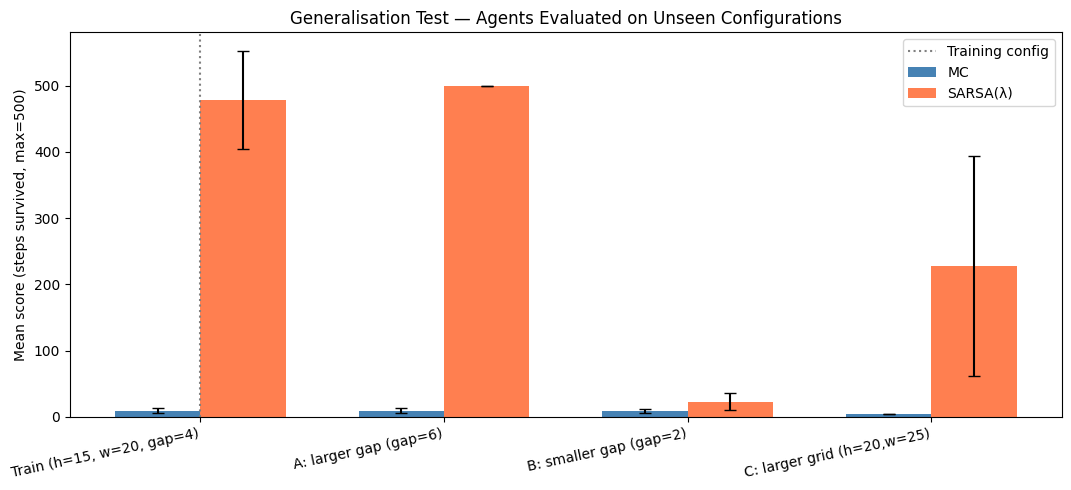

In [43]:
labels = list(test_configs.keys())
x      = np.arange(len(labels))
width  = 0.35

mc_means    = [np.mean(mc_gen[l])    for l in labels]
sarsa_means = [np.mean(sarsa_gen[l]) for l in labels]
mc_stds     = [np.std(mc_gen[l])     for l in labels]
sarsa_stds  = [np.std(sarsa_gen[l])  for l in labels]

fig, ax = plt.subplots(figsize=(11, 5))
bars_mc    = ax.bar(x - width/2, mc_means,    width, yerr=mc_stds,
                    label="MC",       color="steelblue", capsize=4)
bars_sarsa = ax.bar(x + width/2, sarsa_means, width, yerr=sarsa_stds,
                    label="SARSA(λ)", color="coral",     capsize=4)

# Mark training config
ax.axvline(x=0, color="gray", linestyle=":", linewidth=1.5, label="Training config")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=12, ha="right")
ax.set_ylabel("Mean score (steps survived, max=500)")
ax.set_title("Generalisation Test — Agents Evaluated on Unseen Configurations")
ax.legend()
plt.tight_layout()
plt.savefig("results/figures/generalisation.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.4 — Summary

| Config | MC mean | SARSA(λ) mean | Interpretation |
|---|---|---|---|
| Train (gap=4) | 9.0 | 478.9 | Baseline |
| A: gap=6 | 8.8 | 500.0 | Larger margin — training policy transfers fully |
| B: gap=2 | 8.6 | 22.6 | Tighter precision required — policy breaks down |
| C: h=20, w=25 | 4.0 | 228.1 | Expanded dx/dy range — partial transfer via clipping |

**SARSA(λ)** degrades gracefully: the tile coder's boundary clipping maps
out-of-range states to the nearest trained tile rather than returning zero,
preserving approximate behaviour. Config A even improves over training —
the learned policy is more precise than gap=6 demands.

**MC** shows zero generalisation: unseen `(dx, dy)` keys return `Q=0`,
so `argmax` always selects action 0 (fall). Config C confirms this —
`dx > 13` is never in the Q-table, producing mean=4.0 with std=0.0:
the bird falls immediately every episode without exception.

## Section 6 — Environment Analysis

### 6.1 — Two TFB Variants Compared

In [59]:
# Section 6.1 — already instantiated in Section 0, just re-instantiate here
env_v0     = gym.make("TextFlappyBird-v0",        **ENV_CONFIG)
env_screen = gym.make("TextFlappyBird-screen-v0", **ENV_CONFIG)

obs_v0, _     = env_v0.reset(seed=SEED)
obs_screen, _ = env_screen.reset(seed=SEED)

print("=== TextFlappyBird-v0 ===")
print(f"  Observation : {obs_v0}  (type: {type(obs_v0)})")
print(f"  Space       : {env_v0.observation_space}")

print("\n=== TextFlappyBird-screen-v0 ===")
print(f"  Observation shape      : {obs_screen.shape}")
print(f"  Space                  : {env_screen.observation_space}")
print(f"  Unique cell values     : {sorted(set(obs_screen.flatten().tolist()))}")
print(f"  Observation dimensions : {obs_screen.size}  (vs 2 for v0)")
print(f"  Possible states (upper): 3^300 ≈ {3**300:.2e}  (vs {14*22} for v0)")

env_v0.close()
env_screen.close()

=== TextFlappyBird-v0 ===
  Observation : (13, 1)  (type: <class 'tuple'>)
  Space       : Tuple(Discrete(14), Discrete(22, start=-11))

=== TextFlappyBird-screen-v0 ===
  Observation shape      : (20, 15)
  Space                  : Box(0, 3, (20, 15), int32)
  Unique cell values     : [0, 1, 2]
  Observation dimensions : 300  (vs 2 for v0)
  Possible states (upper): 3^300 ≈ 1.37e+143  (vs 308 for v0)


### 6.2 — Limitations of Each Variant

**`TextFlappyBird-v0` (compact state)**
- The state is hand-engineered: `(dx, dy)` assumes domain knowledge about
  which features are sufficient to play the game. The perception problem —
  extracting meaningful structure from raw observations — is already solved
  by the environment designer.
- Cannot be used to study representation learning since the hard part is
  already done upstream.
- Limited to two features: a richer agent tracking velocity or
  acceleration cannot be expressed within this observation.

**`TextFlappyBird-screen-v0` (raw screen)**
- Observation is a `(20, 15)` integer grid — 300 dimensions with values
  in `{0, 1, 2}`, yielding up to `3^300 ≈ 1.37e143` possible states.
  Tabular methods are infeasible at this scale.
- Tile coding over 300 dimensions is computationally intractable — the
  number of tiles grows exponentially with dimensionality.
- Requires non-linear function approximation (e.g. a CNN or MLP) to
  extract spatial structure. Neither MC nor SARSA(λ) as implemented here
  can solve it without architectural changes.
- Slower to run: rendering the full screen at every step adds overhead
  compared to the compact two-value observation.


### 6.3 — Compatibility with Original Flappy Bird Gym

The original environment (`flappy-bird-gym`) uses continuous RGB pixel
observations from the actual game renderer — a much higher-dimensional
space than even `screen-v0`.

**MC (tabular):** Cannot be applied. The continuous observation space has
infinitely many states — a Q-table cannot be constructed.

**SARSA(λ) with tile coding:** Tile coding over high-dimensional pixel
inputs is computationally intractable. Furthermore, tile coding treats
dimensions independently and cannot capture the spatial structure that
makes pixel observations meaningful (e.g. the relative position of the
  bird and pipe).

**What would be needed:** A convolutional neural network to encode the
screen into a compact latent representation, combined with a deep RL
algorithm such as DQN. The core learning principles carry over — TD
error, ε-greedy exploration, and credit assignment — but the linear
`w · x(s)` approximation would need to be replaced by a neural network,
changing the method from semi-gradient SARSA to a deep RL variant.

**In short:** The same algorithms cannot be directly reused, but the
same learning principles underpin modern deep RL methods that can solve
the original game.